# Calling hits against genes that cannot respond

A genome-wide knockout screen asks which genes change the cell when they are removed. Most do not, so the work is telling the genes that moved the cell from the ones that only look like they did. A per-feature test does not settle the question on its own: with thousands of control wells behind it, almost any gene differs from the controls on some feature, and the number that reaches a fixed p-value says more about the test's power than about biology.

PERISCOPE calibrates the call against genes a cell line does not express. DepMap reports expression for the cell line, and a gene it records at zero TPM cannot change anything when it is knocked out, so the scores those genes reach are an empirical null. A real knockout counts as a hit when it scores past what the non-expressed genes reach. This case study builds the per-gene score, reads the null from DepMap, and calls hits with {func}`~mantispy.tl.empirical_fdr` on the JUMP CRISPR screen, which was run in U2OS cells.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact, norm

import mantispy as mt

In [ ]:
wells = mt.ds.jump_crispr()
kinds = wells.obs["Metadata_Control_Type"].astype(str).value_counts().to_dict()
print(wells.shape, kinds)

(51185, 595) {'trt': 43138, 'negcon': 7478, 'poscon': 569}


## A score that rises with the phenotype

The score is how many features separate a gene's wells from the negative controls. For each feature it is a Mann-Whitney test of the gene's wells against the control wells, and the gene's score is the count of features that come out significant. The per-feature Mann-Whitney test is the one PERISCOPE uses, here on JUMP's Cell Painting features rather than PERISCOPE's own. The count is unbounded, so a strong knockout keeps climbing rather than saturating, which matters for the calibration below. The gene is the unit, with its several guides as replicate wells.

In [ ]:
# For each feature, a Mann-Whitney test of every gene's wells against the negative-control wells.
# Vectorized: sort the controls once per feature, then count how many each treated well beats.
Z = norm.isf(0.001 / 2)  # two-sided p of 0.001, by the normal approximation to Mann-Whitney U
X = np.asarray(wells.X, float)
control_type = wells.obs["Metadata_Control_Type"].astype(str).to_numpy()
gene = wells.obs["Metadata_Perturbation"].astype(str).to_numpy()
negcon, treated, treated_gene = X[control_type == "negcon"], X[control_type == "trt"], gene[control_type == "trt"]
usable = np.isfinite(negcon).all(0) & np.isfinite(treated).all(0)

rank = np.zeros_like(treated)
for f in np.where(usable)[0]:
    ordered = np.sort(negcon[:, f])
    below = np.searchsorted(ordered, treated[:, f], "left")
    ties = np.searchsorted(ordered, treated[:, f], "right") - below
    rank[:, f] = below + 0.5 * ties

frame = pd.DataFrame(rank[:, usable])
frame["gene"] = treated_gene
u = frame.groupby("gene").sum().to_numpy()
n1 = frame.groupby("gene").size().to_numpy()[:, None]
n2 = negcon.shape[0]
z = (u - n1 * n2 / 2) / np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
genes = frame.groupby("gene").size().index.to_numpy().astype(str)
score = (np.abs(z) > Z).sum(1).astype(float)  # significant features per gene
print(f"{len(genes)} genes scored, median {np.median(score):.0f}, max {score.max():.0f}")

7974 genes scored, median 5, max 431


## The genes U2OS cannot express

The null is the genes the screened cell line does not express, read from DepMap. Download the expression matrix (`OmicsExpressionProteinCodingGenesTPMLogp1.csv`) from the [DepMap data page](https://depmap.org/portal/data_page/) and point {func}`~mantispy.io.unexpressed_genes` at it. DepMap keys its cell lines by a model id, so the screen's line, U2OS, is named by its id rather than by a looked-up name. A gene the model reports at zero TPM cannot respond to a knockout, so these genes are the empirical null.

In [ ]:
# DepMap's expression matrix, downloaded from the DepMap data page (nothing is re-hosted).
# U2OS, the line this screen was run in, is model ACH-000364 in DepMap's own key.
controls = mt.io.unexpressed_genes("OmicsExpressionProteinCodingGenesTPMLogp1.csv", "ACH-000364")
present = sorted(set(genes) & controls)
print(f"{len(controls)} genes at zero TPM in U2OS, {len(present)} of them screened here")

2137 genes at zero TPM in U2OS, 559 of them screened here


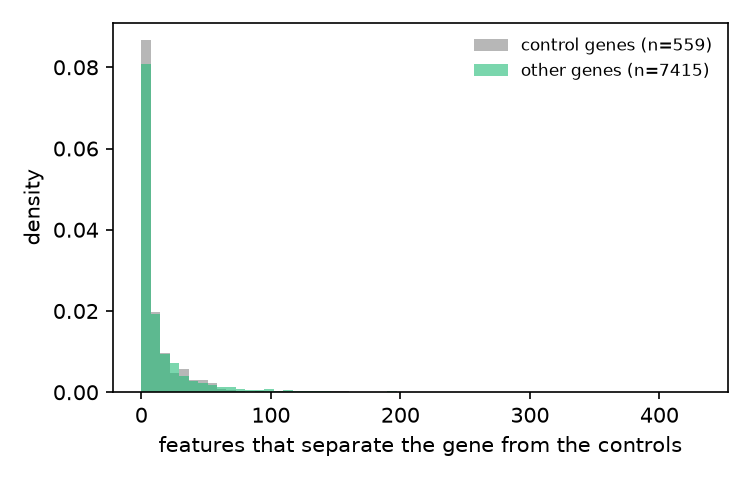

In [ ]:
bins = np.linspace(0, score.max(), 60)
is_control = np.isin(genes, list(controls))
plt.figure(figsize=(5, 3.2))
plt.hist(
    score[is_control], bins=bins, density=True, alpha=0.6, color="#888", label=f"control genes (n={is_control.sum()})"
)
plt.hist(
    score[~is_control], bins=bins, density=True, alpha=0.6, color="#2b7", label=f"other genes (n={(~is_control).sum()})"
)
plt.xlabel("features that separate the gene from the controls")
plt.ylabel("density")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

Most genes sit near zero whether or not they are expressed: a typical knockout separates on a handful of features, and so does a typical non-expressed gene. The hits are the long tail on the right, and the control genes almost never reach it. That gap is what the calibration turns into a rate.

## Calibrating the hit list

{func}`~mantispy.tl.empirical_fdr` takes the per-gene score and the control set and writes two numbers per gene. It wants one row per gene, so the score goes on a small object keyed by gene.

In [ ]:
import anndata as ad

per_gene = ad.AnnData(score.reshape(-1, 1), obs=pd.DataFrame({"score": score}, index=genes))
mt.tl.empirical_fdr(per_gene, control_genes=controls, score="score", alpha=0.01)
mt.tl.empirical_fdr(per_gene, control_genes=controls, score="score", alpha=0.01, criterion="q", key_added="efdr_q")

p = per_gene.obs["empirical_fdr_pvalue"]
q = per_gene.obs["empirical_fdr_qvalue"]
print(f"hits at p<=0.01: {int((p <= 0.01).sum())}")
print(f"hits at q<=0.01: {int((q <= 0.01).sum())}")

hits at p<=0.01: 331
hits at q<=0.01: 102


In [ ]:
hits = per_gene.obs.loc[per_gene.obs["empirical_fdr"], ["score", "empirical_fdr_pvalue", "empirical_fdr_qvalue"]]
print(
    hits.sort_values("score", ascending=False)
    .head(12)
    .to_string(header=["score", "pvalue", "qvalue"], float_format=lambda v: f"{v:.4f}")
)

                score  pvalue  qvalue
     ITGAV  431.0  0.0018  0.0018
      MDM2  422.0  0.0018  0.0018
     PSMD7  384.0  0.0018  0.0018
      NXF1  373.0  0.0018  0.0018
    POLR2A  372.0  0.0018  0.0018
     HSPA5  367.0  0.0018  0.0018
      LRR1  360.0  0.0018  0.0018
     KIF23  344.0  0.0018  0.0018
    TSG101  342.0  0.0018  0.0018
    SUPT6H  331.0  0.0018  0.0018
       RAN  330.0  0.0018  0.0018
    EIF4A3  330.0  0.0018  0.0018


The strongest hits are the machinery a cell cannot run without: RNA polymerase (POLR2A), the proteasome (PSMD7, PSMD14), mRNA export and ribosome biogenesis (NXF1, EIF4A3, RAN), the chaperone HSPA5, the AAA-ATPase VCP, and cell-division genes (KIF23, WEE1, TSG101). These are the genes to follow up.

Two numbers come out, and they answer different questions.

The p-value is the share of control genes that reach a gene's score, with one added to the count and the control total so a gene past every control does not get an exact zero. A cutoff on it fixes the rate at which a control gene is called, the way PERISCOPE sets its threshold, and here it calls 331 genes.

The q-value is a target-decoy false discovery rate. At a gene's score it weighs the share of control genes reaching it against the share of all tested genes reaching it, so it estimates how much of the hit list is false. It accounts for the thousands of genes tested, which the p-value does not, so it is stricter: 102 genes at `q <= 0.01`. It treats every tested gene as a potential null, so it is a conservative bound rather than an exact rate. Quote the q-value as the honest rate, and read the p-value as the PERISCOPE-style cutoff. Every q-hit is also a p-hit.

The `empirical_fdr` call above used `criterion="p"` by default, so `obs["empirical_fdr"]` holds the p-value hit list. Pass `criterion="q"` for the honest list, or read `obs["empirical_fdr_qvalue"]` directly.

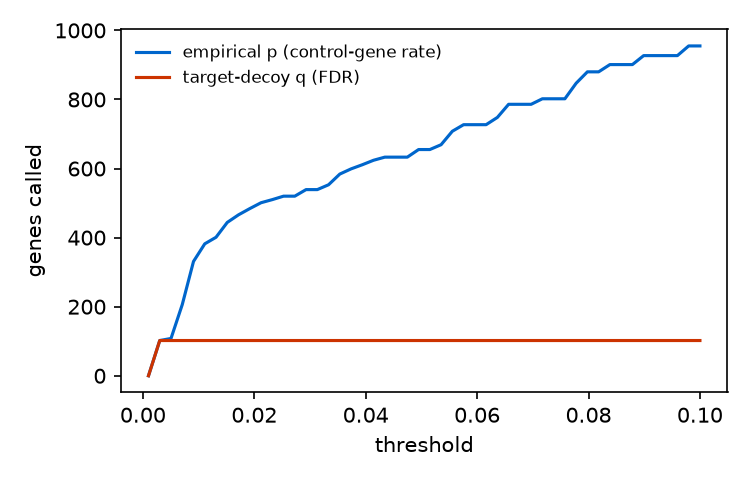

In [ ]:
target = ~is_control
alphas = np.linspace(0.001, 0.1, 50)
pv, qv = p.to_numpy(), q.to_numpy()
plt.figure(figsize=(5, 3.2))
plt.plot(
    alphas, [int(np.nansum(pv[target] <= a)) for a in alphas], color="#06c", label="empirical p (control-gene rate)"
)
plt.plot(alphas, [int(np.nansum(qv[target] <= a)) for a in alphas], color="#c30", label="target-decoy q (FDR)")
plt.xlabel("threshold")
plt.ylabel("genes called")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## Checking the null

If the p-value threshold is set honestly, holding some control genes out and setting the cutoff on the rest should call the held-out ones at about the nominal rate. Split them in half, set the cutoff on one half, and measure the rate on the other.

In [ ]:
rng = np.random.default_rng(0)
order = rng.permutation(np.where(is_control)[0])
fit, test = order[: len(order) // 2], order[len(order) // 2 :]
for a in (0.01, 0.05):
    cutoff = np.quantile(score[fit], 1 - a)
    print(f"nominal {a}: realized {np.mean(score[test] >= cutoff):.4f}")

nominal 0.01: realized 0.0214
nominal 0.05: realized 0.0571


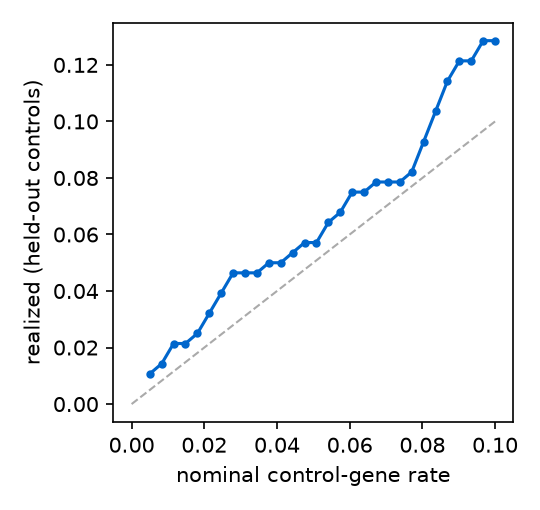

In [ ]:
nominal = np.linspace(0.005, 0.1, 30)
realized = [np.mean(score[test] >= np.quantile(score[fit], 1 - a)) for a in nominal]
plt.figure(figsize=(3.6, 3.4))
plt.plot([0, 0.1], [0, 0.1], "--", color="#aaa", lw=1)
plt.plot(nominal, realized, "o-", ms=3, color="#06c")
plt.xlabel("nominal control-gene rate")
plt.ylabel("realized (held-out controls)")
plt.tight_layout()
plt.show()

The held-out control genes come through near the rate the cutoff promises. The control set is small, a few hundred genes, so the held-out rate is coarse and wanders above and below the line rather than tracking it exactly. The split shows the control set is internally consistent; whether unexpressed genes stand in for a silent expressed gene is a separate assumption the biological check below speaks to.

## The hits in biological terms

A hit list that is right should be enriched for genes that work together. CORUM records which genes share a protein complex, and {func}`~mantispy.ds.corum` returns it. Members of one complex tend to give the same phenotype when knocked out, so they should be over-represented among the hits and rare among the control genes.

In [ ]:
complexes = mt.ds.corum()
in_complex = set(complexes["target"].astype(str))
membership = np.isin(genes, list(in_complex))
hit = target & (np.nan_to_num(pv, nan=1.0) <= 0.01)
q_hit = target & (np.nan_to_num(qv, nan=1.0) <= 0.01)


def enrichment(mask):
    """The in-complex fraction and Fisher odds ratio for a hit mask, against the other tested genes."""
    table = [
        [int((mask & membership).sum()), int((mask & ~membership).sum())],
        [int((target & ~mask & membership).sum()), int((target & ~mask & ~membership).sum())],
    ]
    return np.mean(membership[mask]), fisher_exact(table)[0]


for name, mask in [("p<=1%", hit), ("q<=1%", q_hit)]:
    frac, odds = enrichment(mask)
    print(f"{name} hits ({mask.sum():>3}) in a complex: {frac:.0%}   odds ratio {odds:.1f}")
print(f"other tested genes in a complex: {np.mean(membership[target & ~hit]):.0%}")

p<=1% hits (331) in a complex: 59%   odds ratio 4.7
q<=1% hits (102) in a complex: 76%   odds ratio 10.4
other tested genes in a complex: 23%


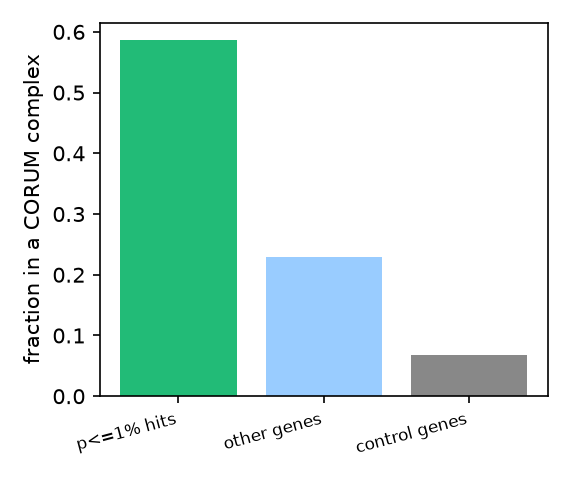

In [ ]:
fractions = [np.mean(membership[hit]), np.mean(membership[target & ~hit]), np.mean(membership[is_control])]
plt.figure(figsize=(3.8, 3.2))
plt.bar(["p<=1% hits", "other genes", "control genes"], fractions, color=["#2b7", "#9cf", "#888"])
plt.ylabel("fraction in a CORUM complex")
plt.xticks(rotation=15, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

Three fifths of the p-value hits belong to a known complex, against a quarter of the other tested genes, a fivefold enrichment that chance does not explain. The honest q-value list is cleaner still: three in four of those genes sit in a complex. The hits read as biology: the proteasome comes through almost whole (PSMA1, PSMB2 through PSMB7, PSMC1, PSMC2), together with ribosomal proteins (RPL4, RPL7, RPS2, RPS23) and the CCT chaperonin (CCT2 through CCT6A). These are the machines a cell cannot lose without changing shape.

## Another cell line

Only one line in the whole analysis names the cell line: the DepMap model id passed to {func}`~mantispy.io.unexpressed_genes`. For a screen run in a different line, download that line's expression once and change the model id, for example `"ACH-001086"` for HeLa. Nothing else changes, and nothing is hard-coded to U2OS.

## Summary

- Score each gene by how many features separate its wells from the negative controls, a Mann-Whitney test per feature.
- Read the genes the screened cell line does not express from DepMap with {func}`~mantispy.io.unexpressed_genes`, keyed by the line's DepMap model id.
- {func}`~mantispy.tl.empirical_fdr` turns the score and the null into a per-gene p-value, the control-gene rate PERISCOPE thresholds, and a target-decoy q-value, the honest false discovery rate.
- On JUMP CRISPR the hit list is enriched several fold for CORUM complex members, recovering the proteasome, the ribosome and the CCT chaperonin.